# Behavioral Counting Analysis


1. **Setup**  
   - Define data paths (`sourcedata_dir`), subject IDs, task names (`covert`/`overt`), and run lists.

2. **Data Loading & Parsing**  
   - For each subject × task × run:  
     - Load all LSL streams from the `.xdf` file.  
     - Select the `KeyboardMarkerStream` and convert its time-series to NumPy arrays.  
     - Identify trials by `start_trial`/`stop_trial` markers and extract each trial’s event codes and values.

3. **Accuracy Computation**  
   - **Strict**: reported count exactly equals presented count.  
   - **Lenient**: reported count is within ±1 of presented.  
   - Record a Boolean correctness list per trial.

4. **Aggregation**  
   - Compute mean and SD of strict/lenient accuracy across trials, for each subject and task.  
   - Store results in a `metrics` dictionary.

5. **Saving**  
   - Bundle all metrics (and `subjects` array) into a compressed NPZ file for downstream use.

6. **Visualization**  
   - Generate barplots showing strict vs. lenient accuracy for covert and overt tasks, one bar per subject.  
   - Add dashed horizontal lines to mark each condition’s overall mean.


In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
@author: RV
"""
import os
import numpy as np
from mnelab.io.xdf import read_raw_xdf as read_raw
import pyxdf
from os.path import join
import warnings
warnings.filterwarnings("ignore")
# Set MNE log level
mne.set_log_level('warning')

def ensure_dir(directory):
    if not os.path.exists(directory):
        os.makedirs(directory)
# Define directories

wd = r'C:\Users\Radovan\OneDrive\Radboud\Studentships\Jordy Thielen\root'
os.chdir(wd)
data_dir = join(wd, "data")
ensure_dir(data_dir)
experiment_dir = join(wd, "data", "experiment")
sourcedata_dir = join(experiment_dir, 'sourcedata')

In [ ]:
import os
import numpy as np
import pyxdf
import matplotlib.pyplot as plt


# Set-up

sourcedata_dir = join(experiment_dir, 'sourcedata')
subjects    = ["VPpdia", "VPpdib", "VPpdic", "VPpdid", "VPpdie", "VPpdif", "VPpdig", "VPpdih", "VPpdii", "VPpdij",
                "VPpdik", "VPpdil", "VPpdim", "VPpdin", "VPpdio", "VPpdip", "VPpdiq", "VPpdir", "VPpdis", "VPpdit",
                "VPpdiu", "VPpdiv", "VPpdiw", "VPpdix", "VPpdiy", "VPpdiz", "VPpdiza", "VPpdizb", "VPpdizc"]
tasks_list  = ['covert', 'overt']   
runs        = {"overt": ["001"], "covert": ["001", "002", "003", "004"]}

# 2. Prepare containers to log data

metrics = {
    'covert_strict':   [], 'covert_strict_sd':   [],
    'covert_lenient':  [], 'covert_lenient_sd':  [],
    'overt_strict':    [], 'overt_strict_sd':    [],
    'overt_lenient':   [], 'overt_lenient_sd':   []
}

# Main Loop
for subject in subjects:
    for task in tasks_list:
        strict_list  = []  # will hold True/False for exact matches
        lenient_list = []  # will hold True/False for ±1 tolerance

        # iterate over all runs in this task
        for run in runs[task]:
            # build the filename and load all LSL streams
            fn = os.path.join(
                sourcedata_dir,
                f"sub-{subject}", "ses-S001", "eeg",
                f"sub-{subject}_ses-S001_task-{task}_run-{run}_eeg.xdf"
            )
            streams, _ = pyxdf.load_xdf(fn, dejitter_timestamps=True)

            # extract the KeyboardMarkerStream for behavioral events
            marker = next(
                s for s in streams
                if s['info']['name'][0] == "KeyboardMarkerStream"
            )

            # convert to numpy arrays for easy indexing
            data  = np.asarray(marker['time_series'])
            codes = data[:, 2]           # event codes 
            vals  = data[:, 3].astype(str)  # corresponding values

            # find indices of trial boundaries
            starts = np.where(codes == "start_trial")[0]
            ends   = np.where(codes == "stop_trial")[0]

            # loop over each trial
            for s_idx, e_idx in zip(starts, ends):
                tcodes = codes[s_idx:e_idx+1]
                tvals  = vals[s_idx:e_idx+1]

                # Determine which side was cued
                cued = tvals[np.where(tcodes == "cued_side")[0][0]]
                cued = cued.strip('"').lower()  #'left' or 'right'

                # Get number of targets presented on that side
                key = f"{cued}_num_targets"
                n_pres = int(float(tvals[np.where(tcodes == key)[0][0]]))

                # Extract subject's response (stop_response)
                resp_idx = np.where(tcodes == "stop_response")[0]
                if resp_idx.size:
                    rep = tvals[resp_idx[0]].strip('"')
                    try:
                        reported = int(rep)
                    except ValueError:
                        reported = None
                else:
                    reported = None

                # 3d. Evaluate strict (exact) and lenient (±1) correctness
                strict_list.append( reported == n_pres )
                lenient_list.append(
                    (reported is not None) and (abs(reported - n_pres) <= 1)
                )


        # 4. Aggregate subject statistics per task

        arr_s = np.array(strict_list,  dtype=float)
        arr_l = np.array(lenient_list, dtype=float)

        metrics[f'{task}_strict'    ].append(arr_s.mean())
        metrics[f'{task}_strict_sd' ].append(arr_s.std(ddof=0))
        metrics[f'{task}_lenient'   ].append(arr_l.mean())
        metrics[f'{task}_lenient_sd'].append(arr_l.std(ddof=0))


manuscript_dir = r'C:\Users\Radovan\OneDrive\Radboud\Studentships\Jordy Thielen\Manuscript\data'
behavioral_dir = join(manuscript_dir, 'behavioral')
ensure_dir(behavioral_dir)
out_fname = join(behavioral_dir, 'behavioral_counting.npz')

# convert lists in metrics to numpy arrays and include subjects
save_dict = {
    'subjects': np.array(subjects)
}
for key, vals in metrics.items():
    save_dict[key] = np.array(vals)

# save compressed .npz
np.savez_compressed(out_fname, **save_dict)

Stream 3: Calculated effective sampling rate 725.7609 Hz is different from specified rate 1000.0000 Hz.
Stream 2: Calculated effective sampling rate 725.5968 Hz is different from specified rate 1000.0000 Hz.
Stream 3: Calculated effective sampling rate 725.7496 Hz is different from specified rate 1000.0000 Hz.
Stream 2: Calculated effective sampling rate 727.0904 Hz is different from specified rate 1000.0000 Hz.
Stream 3: Calculated effective sampling rate 721.9789 Hz is different from specified rate 1000.0000 Hz.
Stream 1: Calculated effective sampling rate 728.9164 Hz is different from specified rate 1000.0000 Hz.
Stream 1: Calculated effective sampling rate 736.8298 Hz is different from specified rate 1000.0000 Hz.
Stream 1: Calculated effective sampling rate 733.6107 Hz is different from specified rate 1000.0000 Hz.
Stream 3: Calculated effective sampling rate 731.3433 Hz is different from specified rate 1000.0000 Hz.
Stream 2: Calculated effective sampling rate 731.9321 Hz is diff

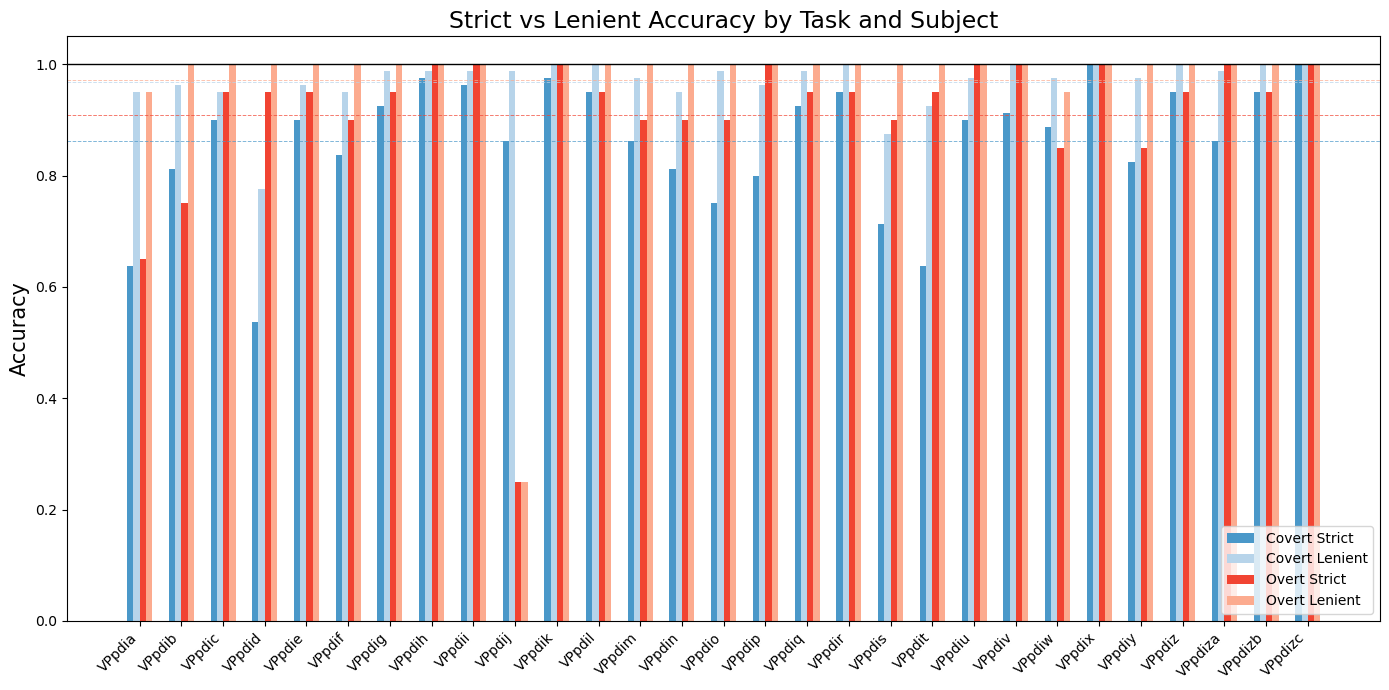

Mean ± SD per condition:
Covert Strict  :  86.2% ±  11.3%
Covert Lenient :  96.8% ±   4.6%
Overt Strict   :  90.9% ±  14.7%
Overt Lenient  :  97.1% ±  13.7%


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

manuscript_dir  = r'C:\Users\Radovan\OneDrive\Radboud\Studentships\Jordy Thielen\Manuscript\data'
behavioral_dir  = join(manuscript_dir, 'behavioral')
out_fname       = join(behavioral_dir, 'behavioral_counting.npz')

# Load the .npz archive
data = np.load(out_fname)

# Extract the subjects array
subjects = data['subjects']


# Params
n_subs = len(subjects)
x = np.arange(n_subs) * 2       # extra spacing between subject groups
bar_width = 0.3                 # wider bars for readability

# (condition_key, display_label, color, offset_multiplier)
conditions = [
    ('covert_strict',  'Covert Strict',  plt.get_cmap('Blues')(0.6), -1.5),
    ('covert_lenient', 'Covert Lenient', plt.get_cmap('Blues')(0.3), -0.5),
    ('overt_strict',   'Overt Strict',   plt.get_cmap('Reds')(0.6),   0.5),
    ('overt_lenient',  'Overt Lenient',  plt.get_cmap('Reds')(0.3),   1.5),
]

# Bar plot
fig, ax = plt.subplots(figsize=(14, 7))
ax.axhline(1, color='k', linestyle='-', linewidth=1)

for key, label, color, offs in conditions:
    positions = x + offs * bar_width
    ax.bar(positions, data[key], bar_width, label=label, color=color)
    
    mean_val = np.array(data[key]).mean()
    ax.axhline(mean_val, color=color, linestyle='--', linewidth=0.7, alpha = 0.7)

ax.set_xticks(x)
ax.set_xticklabels(subjects, rotation=45, ha='right')
ax.set_ylabel('Accuracy', fontsize = 15)
ax.set_title('Strict vs Lenient Accuracy by Task and Subject', fontsize= 17)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Print overall mean ± SD per each condition

print("Mean ± SD per condition:")
for key, label, _, _ in conditions:
    vals = data[key]
    mean_val = np.mean(vals)
    sd_val   = np.std(vals, ddof=0)
    print(f"{label:15s}: {mean_val*100:5.1f}% ± {sd_val*100:5.1f}%")
